## DS2500 Final Project
#### Ethan McGeever & Matthew Lam
######  Deahan Yu Section 1 

Research Question: *“During the 2008 crisis, the 2020 COVID shock, and the 2021-2023 inflation period, which indicators moved first and had the strongest relationship with delinquencies?”*

The structure of our analysis is as follows: 
1) Imports and Aggregation
2) Data Transformations & Lag Effects
3) EDA -- Summary Statistics and Basic Correlation Analysis
4) Advanced Correlation Analysis
5) Findings
6) Conclusion

## Imports & Aggregation

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
# import numpy as np

In [89]:
# Github urls for datasets
pce_health_care_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/17049f085df3b6d5aa927ff99f2829e8fbe70a8a/Datasets/DHLCRG3Q086SBEA.csv'
pce_food_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/4d82c3341b7c1afd971edbc68a52aeafe1707c6d/Datasets/DFXARG3M086SBEA.csv'
pce_energy_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/DNRGRG3M086SBEA.csv'
pce_core_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/16ed26f9fa59b72f00c8a470e3de2a9b44dec472/Datasets/PCEPILFE.csv'
u6_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/U6RATE.csv'
ccard_dr_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/DRCCLACBS.csv'
csm_loan_dr_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/DRCLACBS.csv'
mtg_dr_url = 'https://raw.githubusercontent.com/emcgeever-husky/Lam-McGeever-2500/48732e2febbfa7f766ab4075ef23ed06cf9346be/Datasets/DRSFRMACBS.csv'

# Dataframes
indicators_df = pd.read_csv(pce_health_care_url) + pd.read_csv(pce_food_url) + pd.read_csv(pce_core_url) + pd.read_csv(pce_energy_url) + pd.read_csv(u6_url)
delinquancy_rates_df = pd.read_csv(ccard_dr_url) + pd.read_csv(csm_loan_dr_url) + pd.read_csv(mtg_dr_url)

#### FRED dataset helper function

In [90]:
def load_fred(url, name):
    df = pd.read_csv(url, parse_dates=['observation_date'])
    df = df.rename(columns={df.columns[1]: name, 'observation_date': 'date'})
    return df.set_index('date')

#### Loading the Data

In [91]:
pce_health = load_fred(pce_health_care_url, 'pce_health')
pce_food = load_fred(pce_food_url, 'pce_food')
pce_energy = load_fred(pce_energy_url, 'pce_energy')
pce_core = load_fred(pce_core_url, 'pce_core')
u_6 = load_fred(u6_url, 'U6')

ccard_dr = load_fred(ccard_dr_url, 'ccard_dr')
csm_loan_dr = load_fred(csm_loan_dr_url, 'csm_loan_dr')
mtg_dr = load_fred(mtg_dr_url, 'mtg_dr')

#### Convert Monthly Datasets to Quarterly (Using Last Month of Q)

In [92]:
pce_food = pce_food.resample('QS').last()
pce_energy = pce_energy.resample('QS').last()
u_6 = u_6.resample('QS').last()

In [93]:
indicators_df = pce_health.join([pce_food, pce_core, pce_energy, u_6])
delinquancy_rates_df = ccard_dr.join([csm_loan_dr, mtg_dr])

df_master = indicators_df.join(delinquancy_rates_df)

In [94]:
print(f"Shape of the data: {df_master.shape}\n")

print("Master DataFrame:")
print(df_master.head())

print("\nNull values in each column:")
print(df_master.isnull().sum())

Shape of the data: (116, 8)

Master DataFrame:
            pce_health  pce_food  pce_core  pce_energy   U6  ccard_dr  \
date                                                                    
1997-01-01      62.140    67.951    71.144      55.342  9.1      4.70   
1997-04-01      62.525    68.152    71.600      53.124  8.9      4.73   
1997-07-01      62.758    68.412    71.807      54.711  8.7      4.70   
1997-10-01      62.876    68.486    72.036      53.567  8.5      4.81   
1998-01-01      63.225    68.740    72.210      50.016  8.4      4.76   

            csm_loan_dr  mtg_dr  
date                             
1997-01-01         3.75    2.30  
1997-04-01         3.76    2.28  
1997-07-01         3.71    2.26  
1997-10-01         3.75    2.20  
1998-01-01         3.74    2.20  

Null values in each column:
pce_health     0
pce_food       0
pce_core       0
pce_energy     0
U6             0
ccard_dr       0
csm_loan_dr    0
mtg_dr         0
dtype: int64


## Data Transformations & Lag Effects

#### YoY % Change

In [95]:
df_master["pce_health_yoy"] = df_master["pce_health"].pct_change(4) * 100
df_master["pce_food_yoy"] = df_master["pce_food"].pct_change(4) * 100
df_master["pce_energy_yoy"] = df_master["pce_energy"].pct_change(4) * 100
df_master["pce_core_yoy"] = df_master["pce_core"].pct_change(4) * 100

### Lag Effects

In [96]:
# PCE Healthcare
df_master["pce_health_yoy_6m"] = df_master["pce_health"].pct_change(4) * 100
df_master["pce_health_yoy_1y"] = df_master["pce_health"].pct_change(8) * 100
df_master["pce_health_yoy_2y"] = df_master["pce_health"].pct_change(16) * 100

# PCE Food
df_master["pce_food_yoy_6m"] = df_master["pce_food_yoy"].shift(2) 
df_master["pce_food_yoy_1y"] = df_master["pce_food_yoy"].shift(4) 
df_master["pce_food_yoy_2y"] = df_master["pce_food_yoy"].shift(8) 

# PCE Energy
df_master["pce_energy_yoy_6m"] = df_master["pce_energy_yoy"].shift(2)
df_master["pce_energy_yoy_1y"] = df_master["pce_energy_yoy"].shift(4)
df_master["pce_energy_yoy_2y"] = df_master["pce_energy_yoy"].shift(8)

# PCE Core (excluding food and energy)
df_master["pce_core_yoy_6m"] = df_master["pce_core_yoy"].shift(2)
df_master["pce_core_yoy_1y"] = df_master["pce_core_yoy"].shift(4)
df_master["pce_core_yoy_2y"] = df_master["pce_core_yoy"].shift(8)

## EDA -- Summary Statistics and Basic Correlation Analysis

#### Raw PCE indicator visualization

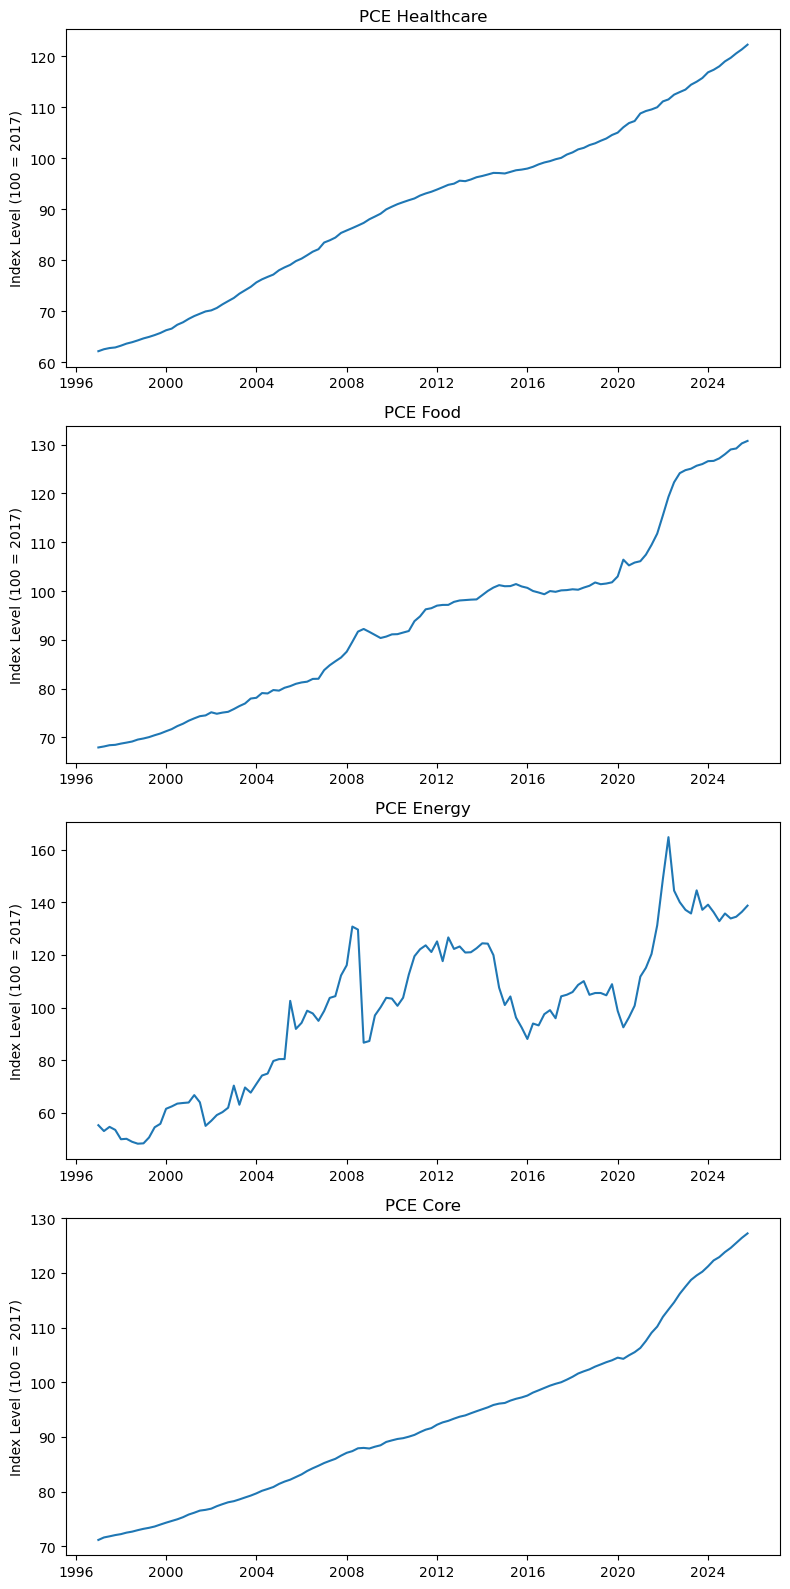

In [97]:
# PCE Healthcare
raw_indicators = ['pce_health', 'pce_food', 'pce_energy', 'pce_core'] 

y_labels = ['Index Level (100 = 2017)', 'Index Level (100 = 2017)', 'Index Level (100 = 2017)', 'Index Level (100 = 2017)']
titles = ['PCE Healthcare', 'PCE Food', 'PCE Energy', 'PCE Core']

fig, axs = plt.subplots(len(raw_indicators), 1, figsize=(8, 4 * len(raw_indicators)))

for axes, col, y_label, title in zip(axs, raw_indicators, y_labels, titles):
    axes.plot(df_master.index, df_master[col])
    axes.set_title(title)
    axes.set_ylabel(y_label)

plt.tight_layout()
plt.show()

#### U6 Visualization

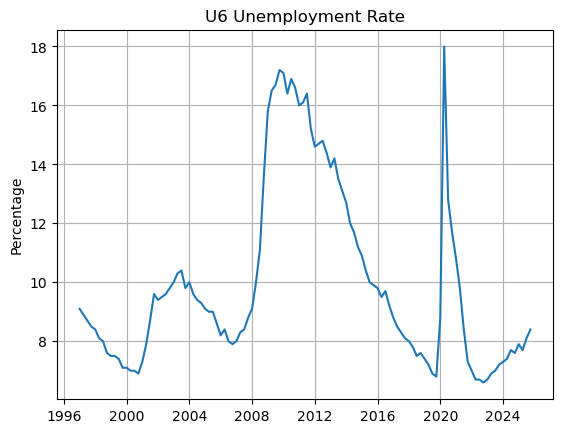

In [100]:
plt.plot(df_master.index, df_master['U6'])
plt.title('U6 Unemployment Rate')
plt.ylabel('Percentage')
plt.grid()
plt.show()

#### Raw PCE Summary Statistics 

In [98]:
indicators_col = ['pce_health', 'pce_food', 'pce_energy', 'pce_core', "U6"]

summary_stats = df_master[indicators_col].describe()
print("Summary Statistics for Key Indicators:")
print(summary_stats)

Summary Statistics for Key Indicators:
       pce_health    pce_food  pce_energy    pce_core          U6
count  116.000000  116.000000  116.000000  116.000000  116.000000
mean    90.433595   93.624526   98.634483   92.802897    9.960345
std     16.901365   17.460024   28.367396   15.074151    3.054715
min     62.140000   67.951000   48.317000   71.144000    6.600000
25%     76.091500   78.793500   73.417750   80.024250    7.700000
50%     92.875500   95.528500  101.785500   91.100500    8.950000
75%    102.162000  101.253750  121.067000  102.096000   10.950000
max    122.269000  130.758000  164.761000  127.245000   18.000000


## Advanced Correlation Analysis

## Findings

## Conclusion